In [22]:
import os
import numpy as np
import scipy.io
import scipy.ndimage
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import h5py

In [ ]:

MAT_PATH = "data/assignmentSegmentBrainGmmEmMrf.mat"
OUTPUT_DIR = "output_segment"
K = 3
BETA = 1.0         
MAX_ITERS = 60
TOL = 1e-4
MIN_VAR = 1e-6
IMAGE_VAR = None    
MASK_VAR = None

In [ ]:
def display_and_save(img, title, fname, cmap='gray', vmin=None, vmax=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    outpath = os.path.join(OUTPUT_DIR, fname)
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()  
    plt.close()
    print("Saved", outpath)

In [ ]:
def gaussian_logpdf(x, mu, sigma2):
    return -0.5 * (np.log(2*np.pi*sigma2) + ((x - mu)**2) / sigma2)

def neighbor_count_maps(labels, K): 
    H, W = labels.shape
    maps = np.zeros((H,W,K), dtype=np.float32)
    footprint = np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=np.uint8)
    for k in range(K):
        indicator = (labels == k).astype(np.uint8)
        maps[:,:,k] = scipy.ndimage.convolve(indicator.astype(np.float32), footprint, mode='constant', cval=0.0)
    return maps

def mean_field_update_memberships(img, mask, mus, sig2s, beta, r_prev):
    H, W = img.shape
    K = mus.size
    ll = np.zeros((H,W,K), dtype=float)
    for k in range(K):
        ll[:,:,k] = gaussian_logpdf(img, mus[k], sig2s[k])
    
    footprint = np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=np.float32)
    prior_term = np.zeros_like(ll)
    for k in range(K):
        prior_term[:,:,k] = beta * scipy.ndimage.convolve(r_prev[:,:,k], footprint, mode='constant', cval=0.0) 
    log_post = ll + prior_term
    maxlog = np.max(log_post, axis=2, keepdims=True)
    post_unnorm = np.exp(log_post - maxlog)
    post_unnorm *= mask[:,:,None]  
    denom = np.sum(post_unnorm, axis=2, keepdims=True)
    denom[denom == 0] = 1.0
    r_new = post_unnorm / denom
    return r_new

def m_step_update_parameters(img, mask, r):
  
    masked = mask == 1
    K = r.shape[2]
    mus = np.zeros(K, dtype=float)
    sig2s = np.zeros(K, dtype=float)
    for k in range(K):
        rk = r[:,:,k] * masked
        sum_rk = rk.sum()
        if sum_rk < 1e-8:
            mus[k] = 0.0
            sig2s[k] = 1.0
            continue
        mus[k] = (rk * img).sum() / sum_rk
        sig2s[k] = ((rk * (img - mus[k])**2).sum() / sum_rk)
        if sig2s[k] < MIN_VAR:
            sig2s[k] = MIN_VAR
    return mus, sig2s

def compute_label_log_posterior(img, labels, mus, sig2s, beta, mask):
   
    H, W = img.shape
    ll = 0.0
    for k in range(mus.size):
        mask_k = (labels == k)
        ll += gaussian_logpdf(img, mus[k], sig2s[k])[mask_k].sum()
    
    footprint = np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=np.uint8)
    pair_sum = 0.0
    for k in range(mus.size):
        indicator = (labels == k).astype(np.float32)
        pair_sum += (indicator * scipy.ndimage.convolve(indicator, footprint, mode='constant', cval=0.0)).sum()
    
    pair_sum = pair_sum / 2.0
    total = ll + beta * pair_sum
    return total

def modified_icm_update(img, mask, mus, sig2s, beta, labels):
   
    H, W = img.shape
    K = mus.size

    ll = np.zeros((H,W,K), dtype=float)
    for k in range(K):
        ll[:,:,k] = gaussian_logpdf(img, mus[k], sig2s[k])
    
    neigh_counts = neighbor_count_maps(labels, K)
    scores = ll + beta * neigh_counts
    
    scores = np.where(mask[:,:,None] == 0, -np.inf, scores)
    labels_new = np.argmax(scores, axis=2)
   
    labels_new[mask==0] = -1
   
    before = compute_label_log_posterior(img, labels, mus, sig2s, beta, mask)
    after = compute_label_log_posterior(img, labels_new, mus, sig2s, beta, mask)
    if after >= before:
        accepted = True
        return labels_new, accepted, before, after
    else:
        
        return labels, False, before, after

def initialize_by_kmeans(img, mask, K):

    ys = img[mask==1].reshape(-1,1)
    km = KMeans(n_clusters=K, random_state=0, n_init=10).fit(ys)
    labels_k = np.full(img.shape, -1, dtype=int)
    labels_k[mask==1] = km.labels_
    mus = km.cluster_centers_.flatten()
    sig2s = np.zeros(K, dtype=float)
    for k in range(K):
        members = ys[km.labels_ == k].flatten()
        if members.size > 0:
            sig2s[k] = members.var() + MIN_VAR
        else:
            sig2s[k] = np.var(ys) + MIN_VAR
   
    H,W = img.shape
    r = np.zeros((H,W,K), dtype=float)
    for k in range(K):
        r[:,:,k] = (labels_k == k).astype(float)
    
    r = r + 1e-6
    r = r / r.sum(axis=2, keepdims=True)
    return mus, sig2s, r, labels_k

In [26]:
def run_em_mrf(img, mask, K, beta, max_iters=50, tol=1e-4, verbose=True):
    H,W = img.shape
    # init
    mus, sig2s, r, labels = initialize_by_kmeans(img, mask, K)
    if verbose:
        print("Initial means:", mus)
        print("Initial variances:", sig2s)
    logpost_history = []
    for it in range(max_iters):
        # E-step (mean-field for memberships)
        r_old = r.copy()
        r = mean_field_update_memberships(img, mask, mus, sig2s, beta, r_old)
        # M-step: update gaussian params
        mus, sig2s = m_step_update_parameters(img, mask, r)
        # compute label image (MAP of memberships)
        labels_map = np.argmax(r, axis=2)
        labels_map[mask==0] = -1
        # Modified ICM update (all labels at once; accept only if global posterior increases)
        labels, accepted, before_lp, after_lp = modified_icm_update(img, mask, mus, sig2s, beta, labels_map)
        logpost_history.append(after_lp if accepted else before_lp)
        # update soft assignments to match labels (hard assignments) optionally:
        # we set r to one-hot of labels for masked area (stabilizes)
        for k in range(K):
            r[:,:,k] = (labels == k).astype(float)
        # small smoothing to avoid zeros
        r = r + 1e-8
        r = r / r.sum(axis=2, keepdims=True)
        # convergence check on parameters or logpost change
        if it > 0 and abs(logpost_history[-1] - logpost_history[-2]) < tol:
            if verbose:
                print(f"Converged at iter {it}. logpost change {abs(logpost_history[-1] - logpost_history[-2])}")
            break
        if verbose:
            print(f"Iter {it}: mus={np.round(mus,3)}, sig2s={np.round(sig2s,4)}, ICM accepted={accepted}, logpost_before={before_lp:.2f}, after={after_lp:.2f}")
    # final memberships: use mean-field one more time with final parameters
    r_final = mean_field_update_memberships(img, mask, mus, sig2s, beta, r)
    # final label map
    labels_final = np.argmax(r_final, axis=2)
    labels_final[mask==0] = -1
    return {
        'mus': mus,
        'sig2s': sig2s,
        'memberships': r_final,
        'labels': labels_final,
        'logpost_history': logpost_history
    }


In [27]:
def normalize_display(img):
    # scale to 0..1 for display
    mn, mx = np.min(img), np.max(img)
    if mx - mn < 1e-9:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

MAT keys: ['imageData', 'imageMask']
Auto-picked image variable: imageData
Auto-picked mask variable: imageMask


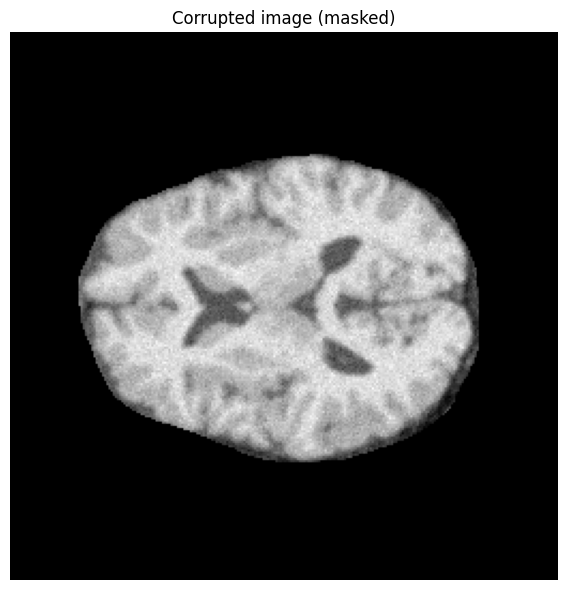

Saved output_segment/corrupted_image.png
Running EM+MRF with beta = 1.0
Initial means: [0.62842053 0.5048575  0.26980602]
Initial variances: [0.0013593  0.00195399 0.00599142]
Iter 0: mus=[0.628 0.511 0.279], sig2s=[0.0015 0.0021 0.0068], ICM accepted=True, logpost_before=72362.62, after=72630.07
Iter 1: mus=[0.63  0.515 0.285], sig2s=[0.0015 0.0019 0.0073], ICM accepted=True, logpost_before=72784.73, after=72870.67
Iter 2: mus=[0.63  0.517 0.289], sig2s=[0.0014 0.0018 0.0076], ICM accepted=True, logpost_before=72918.61, after=72981.61
Iter 3: mus=[0.631 0.518 0.292], sig2s=[0.0014 0.0018 0.0079], ICM accepted=True, logpost_before=72989.76, after=73053.85
Iter 4: mus=[0.631 0.519 0.294], sig2s=[0.0014 0.0017 0.008 ], ICM accepted=True, logpost_before=73051.96, after=73114.84
Iter 5: mus=[0.631 0.519 0.295], sig2s=[0.0014 0.0017 0.0082], ICM accepted=True, logpost_before=73116.18, after=73165.19
Iter 6: mus=[0.631 0.52  0.296], sig2s=[0.0014 0.0016 0.0082], ICM accepted=True, logpost_be

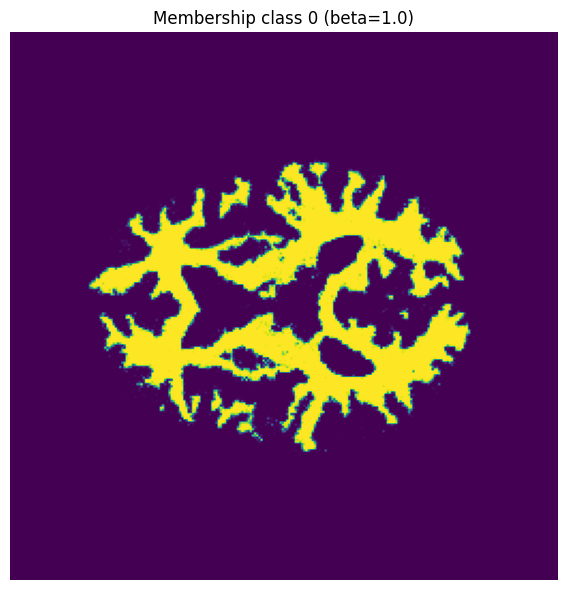

Saved output_segment/membership_beta1.0_class0.png


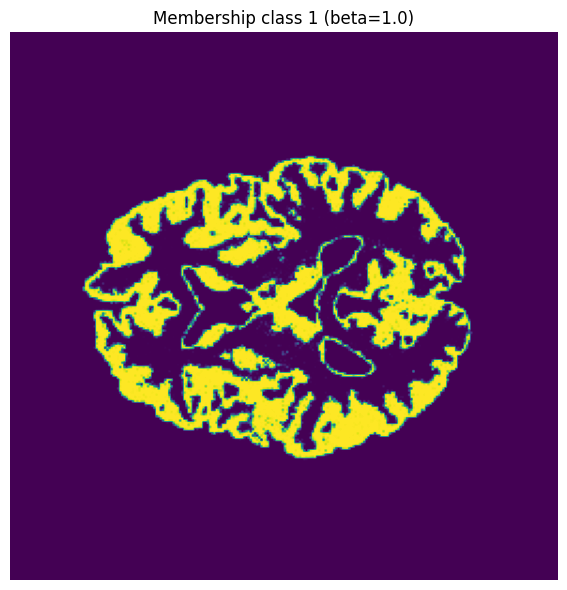

Saved output_segment/membership_beta1.0_class1.png


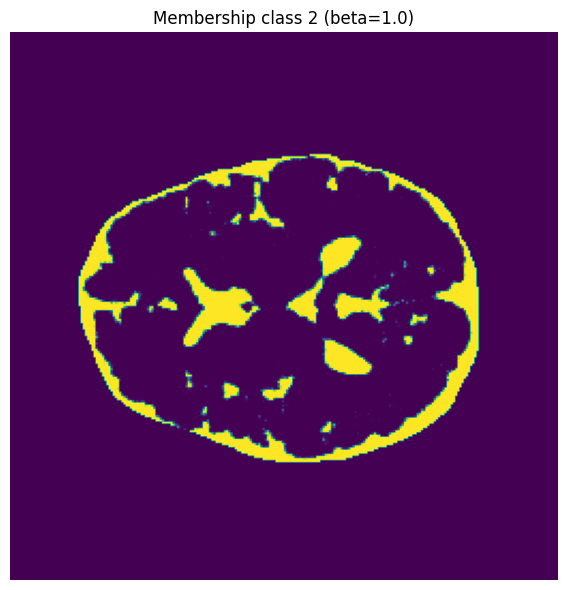

Saved output_segment/membership_beta1.0_class2.png


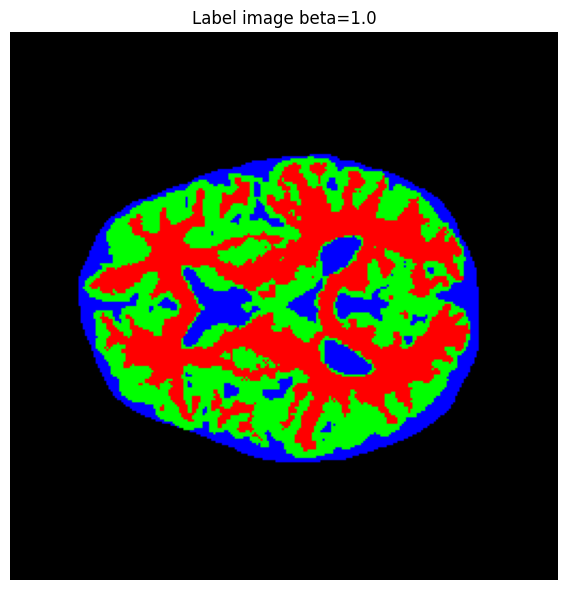

Saved output_segment/labels_beta1.0.png
Running EM with beta = 0 (no MRF prior) for comparison.
Initial means: [0.62842053 0.5048575  0.26980602]
Initial variances: [0.0013593  0.00195399 0.00599142]
Iter 0: mus=[0.628 0.514 0.289], sig2s=[0.0016 0.0019 0.0078], ICM accepted=True, logpost_before=36392.21, after=36545.42
Iter 1: mus=[0.628 0.52  0.304], sig2s=[0.0016 0.0018 0.0095], ICM accepted=True, logpost_before=36502.60, after=36593.13
Iter 2: mus=[0.629 0.524 0.319], sig2s=[0.0016 0.0017 0.0112], ICM accepted=True, logpost_before=36527.96, after=36584.73
Iter 3: mus=[0.63  0.527 0.332], sig2s=[0.0016 0.0016 0.0127], ICM accepted=True, logpost_before=36497.21, after=36529.91
Iter 4: mus=[0.631 0.529 0.344], sig2s=[0.0015 0.0016 0.0141], ICM accepted=True, logpost_before=36432.19, after=36455.75
Iter 5: mus=[0.632 0.53  0.353], sig2s=[0.0015 0.0015 0.0154], ICM accepted=True, logpost_before=36360.87, after=36372.75
Iter 6: mus=[0.633 0.531 0.361], sig2s=[0.0014 0.0015 0.0163], ICM a

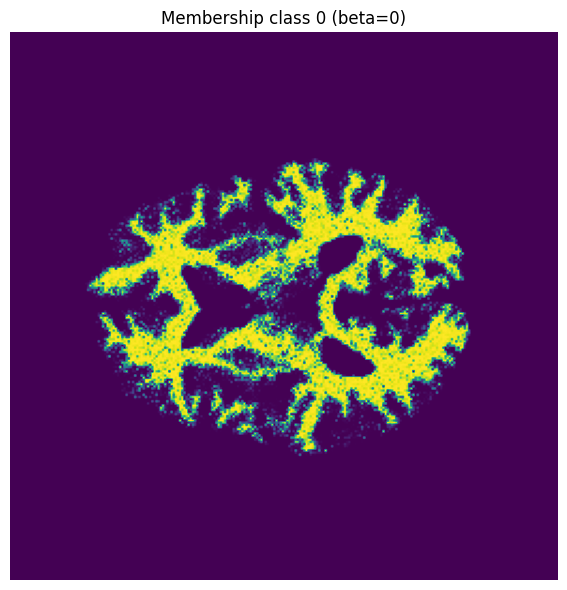

Saved output_segment/membership_beta0_class0.png


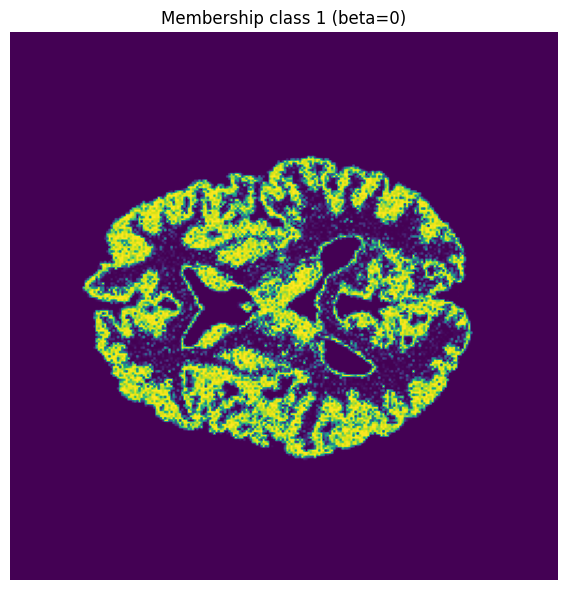

Saved output_segment/membership_beta0_class1.png


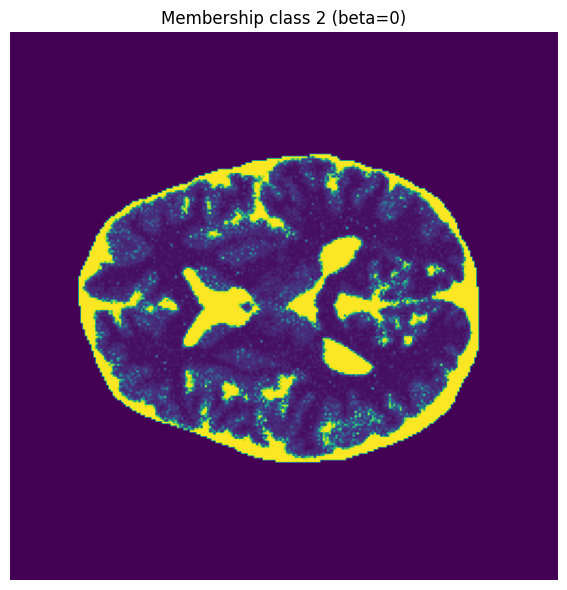

Saved output_segment/membership_beta0_class2.png


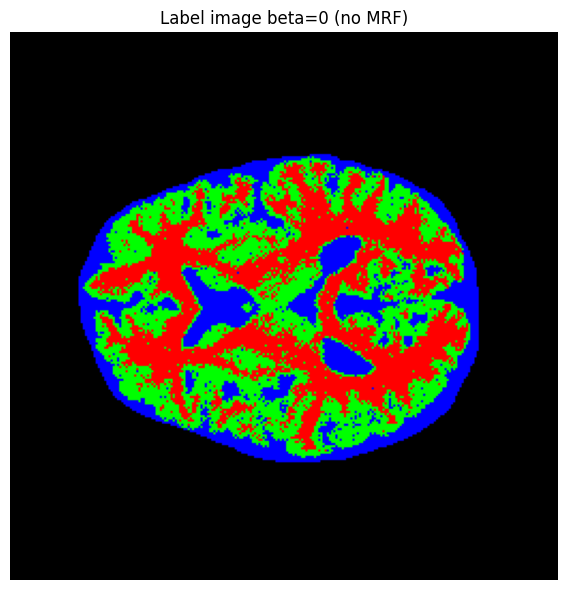

Saved output_segment/labels_beta0.png
=== RESULTS ===
Chosen beta: 1.0
Final class means (beta): [0.63156483 0.52055374 0.29844658]
Final class stddevs (beta): [0.03714287 0.04002577 0.09175751]
Final class means (beta=0): [0.63582924 0.53465724 0.37956201]
Final class stddevs (beta=0): [0.03522537 0.03835527 0.13607467]
Saved all images to output_segment


In [28]:

img, mask = load_mat(MAT_PATH)
# ensure 2D arrays
if img.ndim != 2:
    raise RuntimeError("Expected 2D image in mat file.")
# show corrupted image
display_and_save(img * mask, "Corrupted image (masked)", "corrupted_image.png")
# Run for chosen beta
print("Running EM+MRF with beta =", BETA)
res_beta = run_em_mrf(img, mask, K, beta=BETA, max_iters=MAX_ITERS, tol=TOL, verbose=True)
# Save membership maps
for k in range(K):
    display_and_save(normalize_display(res_beta['memberships'][:,:,k]), f"Membership class {k} (beta={BETA})", f"membership_beta{BETA}_class{k}.png", cmap='viridis')
# Save label image (colored)
label_img = res_beta['labels'].copy()
# create a simple color map for 3 classes
cmap = np.array([[255,0,0],[0,255,0],[0,0,255]], dtype=np.uint8)
H,W = label_img.shape
color_label = np.zeros((H,W,3), dtype=np.uint8)
for k in range(K):
    color_label[label_img==k] = cmap[k]
display_and_save(color_label, f"Label image beta={BETA}", f"labels_beta{BETA}.png", cmap=None)
# Run with beta = 0 (no MRF)
print("Running EM with beta = 0 (no MRF prior) for comparison.")
res_beta0 = run_em_mrf(img, mask, K, beta=0.0, max_iters=MAX_ITERS, tol=TOL, verbose=True)
for k in range(K):
    display_and_save(normalize_display(res_beta0['memberships'][:,:,k]), f"Membership class {k} (beta=0)", f"membership_beta0_class{k}.png", cmap='viridis')
label_img0 = res_beta0['labels'].copy()
color_label0 = np.zeros((H,W,3), dtype=np.uint8)
for k in range(K):
    color_label0[label_img0==k] = cmap[k]
display_and_save(color_label0, "Label image beta=0 (no MRF)", "labels_beta0.png", cmap=None)
# Print chosen parameters
print("=== RESULTS ===")
print("Chosen beta:", BETA)
print("Final class means (beta):", res_beta['mus'])
print("Final class stddevs (beta):", np.sqrt(res_beta['sig2s']))
print("Final class means (beta=0):", res_beta0['mus'])
print("Final class stddevs (beta=0):", np.sqrt(res_beta0['sig2s']))
print("Saved all images to", OUTPUT_DIR)